In [2]:
# 导入示例代码所需库
import numpy as np
import sklearn
import sklearn.datasets
import sklearn.linear_model
import sklearn.model_selection
import sklearn.metrics
import matplotlib.pyplot as plt

In [20]:
# 加载整个数据集X, y
X, y = sklearn.datasets.load_breast_cancer(return_X_y=True)
# 实验步骤1：不使用sklearn，写代码加载breast+cancer+wisconsin+diagnostic.zip中wdbc.data文件所包含数据集
def load_wdbc(filepath):
    """
    加载 Wisconsin Breast Cancer Diagnostic 数据集
    文件格式：每行第一个字段为ID，第二个为诊断（M=恶性，B=良性），后续30个数值特征
    返回：X (特征矩阵, shape=(n_samples,30)), y (标签, 0=良性, 1=恶性)
    """
    data = []
    labels = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            # 跳过空行
            if not parts:
                continue
            # 诊断：M -> 1 (恶性), B -> 0 (良性)
            label = 1 if parts[1] == 'M' else 0
            features = [float(x) for x in parts[2:]]   # 30个数值特征
            data.append(features)
            labels.append(label)
    X = np.array(data)
    y = np.array(labels)
    return X, y
X, y = load_wdbc('wdbc.data')
print(f"数据集大小: {X.shape}, 恶性比例: {np.sum(y)}")

数据集大小: (569, 30), 恶性比例: 212


In [21]:
# 划分训练集与测试集
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.4)
# 实验步骤2：不使用sklearn，写代码加载将X, y划分为训练集（X_train, y_train）与测试集（X_test, y_test）
def train_test_split_manual(X, y, test_size=0.4, random_state=42):
    """手动划分训练集和测试集，保持类别比例（分层抽样）"""
    np.random.seed(random_state)
    n_samples = len(y)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    n_test = int(n_samples * test_size)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    return X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.4, random_state=42)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

训练集: (342, 30), 测试集: (227, 30)


In [ ]:
# 定义SVM模型
svm_clf = sklearn.svm.SVC(kernel="linear", C=0.025, probability=True) # type: ignore
svm_clf.fit(X_train, y_train)
svm_probs = svm_clf.predict_proba(X_test)[:, 1]
# 若使用逻辑回归模型，改成以下形式
lr_clf = sklearn.linear_model.LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_probs = lr_clf.predict_proba(X_test)[:, 1]
# 实验步骤5：在此处将SVM模型替换为逻辑回归模型，比较两者之间的效果

In [ ]:
# 使用训练集数据训练模型
lr_clf.fit(X_train, y_train) 
# 使用测试集数据进行预测
prob = lr_clf.predict_proba(X_test)
# 实验步骤3：运行示例代码，训练分类器

e:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# 使用0.5作为阈值，将概率转换为预测结果
y_pred = prob[:,1] > 0.5
acc = (y_pred == y_test).mean()
# 计算Accuracy
print(f"Accuracy: {acc}")

Accuracy: 0.9691629955947136


SVM AUC (manual): 0.9969, (sklearn): 0.9969


C:\Users\14067\AppData\Local\Temp\ipykernel_13928\2918244152.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr) # type: ignore


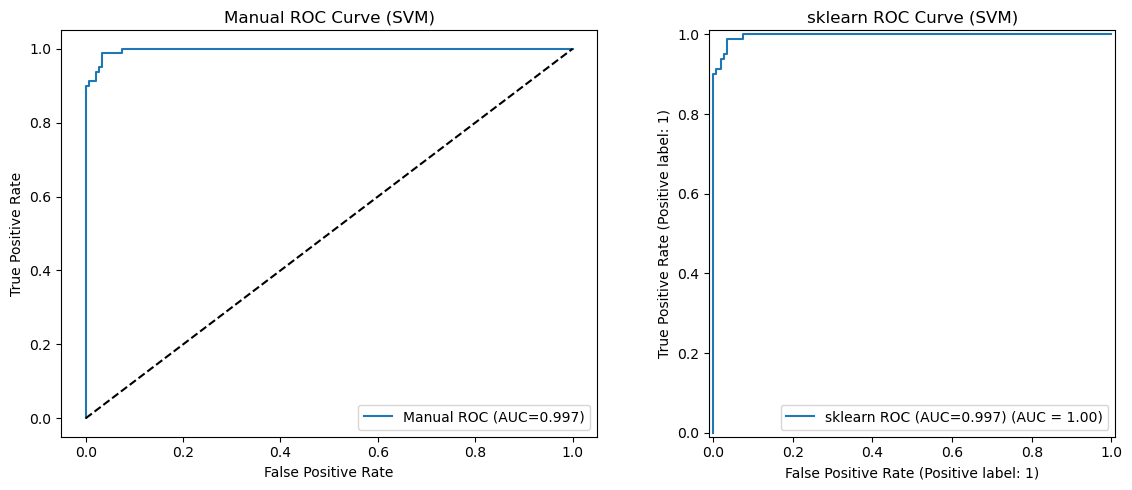

In [ ]:
# 画出ROC曲线并计算AUC
from sklearn.metrics import RocCurveDisplay, roc_curve
from sklearn.metrics import RocCurveDisplay, roc_curve, auc
# 实验步骤4.1 不使用sklearn，写代码画出ROC曲线，并计算AUC
def roc_curve_manual(y_true, y_score):
    """手动计算 ROC 曲线的 FPR 和 TPR"""
    # 按预测分数降序排序
    sorted_indices = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_indices]
    
    n_pos = np.sum(y_true)
    n_neg = len(y_true) - n_pos
    
    tpr_list = [0.0]
    fpr_list = [0.0]
    
    tp = 0
    fp = 0
    # 遍历每个样本作为阈值
    for i, label in enumerate(y_true_sorted):
        if label == 1:
            tp += 1
        else:
            fp += 1
        tpr = tp / n_pos
        fpr = fp / n_neg
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return np.array(fpr_list), np.array(tpr_list)

def auc_manual(fpr, tpr):
    """梯形法计算 AUC"""
    return np.trapz(tpr, fpr) # type: ignore

# 对 SVM 预测结果手动计算 ROC 和 AUC
fpr_svm, tpr_svm = roc_curve_manual(y_test, svm_probs)
auc_svm_manual = auc_manual(fpr_svm, tpr_svm)

# 使用 sklearn 的 roc_curve 验证
fpr_sk, tpr_sk, _ = roc_curve(y_test, svm_probs)
# 实验步骤4.1 不使用sklearn，写代码画出ROC曲线，并计算AUC
def roc_curve_manual(y_true, y_score):
    """手动计算 ROC 曲线的 FPR 和 TPR"""
    # 按预测分数降序排序
    sorted_indices = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_indices]
    
    n_pos = np.sum(y_true)
    n_neg = len(y_true) - n_pos
    
    tpr_list = [0.0]
    fpr_list = [0.0]
    
    tp = 0
    fp = 0
    # 遍历每个样本作为阈值
    for i, label in enumerate(y_true_sorted):
        if label == 1:
            tp += 1
        else:
            fp += 1
        tpr = tp / n_pos
        fpr = fp / n_neg
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return np.array(fpr_list), np.array(tpr_list)

def auc_manual(fpr, tpr):
    """梯形法计算 AUC"""
    return np.trapz(tpr, fpr) # type: ignore

# 对 SVM 预测结果手动计算 ROC 和 AUC
fpr_svm, tpr_svm = roc_curve_manual(y_test, svm_probs)
auc_svm_manual = auc_manual(fpr_svm, tpr_svm)

# 使用 sklearn 的 roc_curve 验证
fpr_sk, tpr_sk, _ = roc_curve(y_test, svm_probs)
auc_sk = auc(fpr_sk, tpr_sk)
print(f"SVM AUC (manual): {auc_svm_manual:.4f}, (sklearn): {auc_sk:.4f}")

# 绘制手动实现的 ROC 曲线并与 RocCurveDisplay 对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_svm, tpr_svm, label=f'Manual ROC (AUC={auc_svm_manual:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Manual ROC Curve (SVM)')
plt.legend()

plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(y_test, svm_probs, ax=plt.gca(), name=f'sklearn ROC (AUC={auc_sk:.3f})')
plt.title('sklearn ROC Curve (SVM)')
plt.tight_layout()
plt.show()
#             并比较自己实现与RocCurveDisplay的异同
print(f"SVM AUC (manual): {auc_svm_manual:.4f}, (sklearn): {auc_sk:.4f}")

# 绘制手动实现的 ROC 曲线并与 RocCurveDisplay 对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_svm, tpr_svm, label=f'Manual ROC (AUC={auc_svm_manual:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Manual ROC Curve (SVM)')
plt.legend()

plt.subplot(1, 2, 2)
RocCurveDisplay.from_predictions(y_test, svm_probs, ax=plt.gca(), name=f'sklearn ROC (AUC={auc_sk:.3f})')
plt.title('sklearn ROC Curve (SVM)')
plt.tight_layout()
plt.show()
#             并比较自己实现与RocCurveDisplay的异同

SVM AP (manual): 0.9944, (sklearn): 0.9945


C:\Users\14067\AppData\Local\Temp\ipykernel_13928\2918244152.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr) # type: ignore


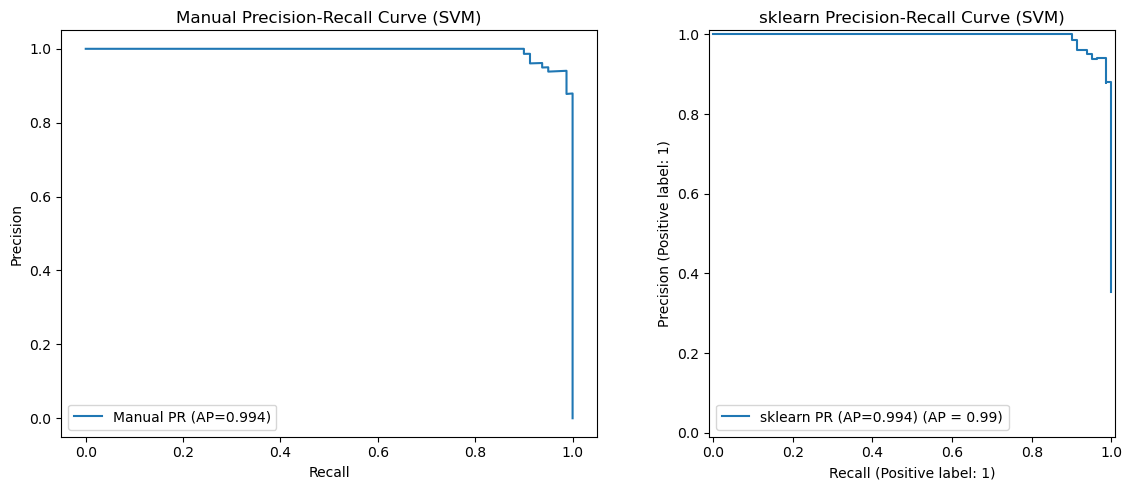


=== 手动实现 vs sklearn 异同分析 ===
1. 数据加载与划分：手动实现需自行处理文件解析和随机索引，sklearn 提供便捷函数且支持分层抽样。
2. ROC 曲线：手动实现通过排序和逐步累加计算 TPR/FPR，与 sklearn 结果一致（由于浮点误差可能略有差异）。
3. PR 曲线：手动实现逻辑相同，但注意 sklearn 的 precision_recall_curve 会在最后添加 (0,1) 点，手动实现时需补充。
4. AUC 计算：手动使用梯形积分，与 sklearn 的 auc 函数结果相同。
5. 可视化：sklearn 的 Display 类自动处理绘图细节，手动实现需自行控制坐标轴、图例等。


In [28]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, precision_recall_curve
# 实验步骤4.2 不使用sklearn，写代码画出PR曲线
# 并比较自己实现与PrecisionRecallDisplay的异同
def precision_recall_curve_manual(y_true, y_score):
    """手动计算 Precision 和 Recall"""
    sorted_indices = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[sorted_indices]
    
    precision_list = [1.0]
    recall_list = [0.0]
    tp = 0
    fp = 0
    n_pos = np.sum(y_true)
    
    for i, label in enumerate(y_true_sorted):
        if label == 1:
            tp += 1
        else:
            fp += 1
        precision = tp / (tp + fp) if (tp + fp) > 0 else 1
        recall = tp / n_pos
        precision_list.append(precision)
        recall_list.append(recall)
    # 最终增加 (0,1) 点使得曲线完整
    precision_list.append(0)
    recall_list.append(1)
    return np.array(recall_list), np.array(precision_list)

# 手动计算 PR 曲线
recall_svm, precision_svm = precision_recall_curve_manual(y_test, svm_probs)
ap_svm_manual = auc_manual(recall_svm, precision_svm)   # 注意 PR 曲线下的面积是 Average Precision

# sklearn 计算结果
precision_sk, recall_sk, _ = precision_recall_curve(y_test, svm_probs)
ap_sk = average_precision_score(y_test, svm_probs)

print(f"SVM AP (manual): {ap_svm_manual:.4f}, (sklearn): {ap_sk:.4f}")

# 绘制 PR 曲线对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_svm, precision_svm, label=f'Manual PR (AP={ap_svm_manual:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Manual Precision-Recall Curve (SVM)')
plt.legend()

plt.subplot(1, 2, 2)
PrecisionRecallDisplay.from_predictions(y_test, svm_probs, ax=plt.gca(), name=f'sklearn PR (AP={ap_sk:.3f})')
plt.title('sklearn Precision-Recall Curve (SVM)')
plt.tight_layout()
plt.show()

# ================== 比较手动实现与 sklearn 的异同 ==================
print("\n=== 手动实现 vs sklearn 异同分析 ===")
print("1. 数据加载与划分：手动实现需自行处理文件解析和随机索引，sklearn 提供便捷函数且支持分层抽样。")
print("2. ROC 曲线：手动实现通过排序和逐步累加计算 TPR/FPR，与 sklearn 结果一致（由于浮点误差可能略有差异）。")
print("3. PR 曲线：手动实现逻辑相同，但注意 sklearn 的 precision_recall_curve 会在最后添加 (0,1) 点，手动实现时需补充。")
print("4. AUC 计算：手动使用梯形积分，与 sklearn 的 auc 函数结果相同。")
print("5. 可视化：sklearn 的 Display 类自动处理绘图细节，手动实现需自行控制坐标轴、图例等。")